In [ ]:
Delhivery Logistics: Operational Intelligence & Optimization
Project Goal: To analyze 140k+ rows of trip data to identify delivery bottlenecks, validate OSRM (Open Source Routing Machine) accuracy, 
and engineer features for better risk identification.

In [1]:
# --- 1. IMPORT LIBRARIES & LOAD DATA ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visual style for plots
sns.set_theme(style="whitegrid")

# Load dataset - Ensure the csv is in the same directory
try:
    df = pd.read_csv('delhivery_data.csv')
    print(f"Dataset loaded successfully with {df.shape[0]} rows and {df.shape[1]} columns.")
except FileNotFoundError:
    print("Error: 'delhivery_data.csv' not found. Please ensure the file is in the working directory.")

# --- 2. INITIAL DATA PROFILING ---
# Checking for missing values to ensure data quality
null_report = df.isnull().sum()
print("\nMissing Values Audit:")
print(null_report[null_report > 0]) # Only show columns that actually have nulls

Dataset loaded successfully with 144867 rows and 24 columns.

Missing Values Audit:
source_name         293
destination_name    261
dtype: int64


In [ ]:
2. Data Preprocessing & Type Casting
Converting timestamp strings to datetime objects and handling missing values in location names to enable time-series analysis.

In [2]:
# --- 3. DATA PREPROCESSING & TYPE CASTING ---

# 1. Convert timestamp columns to datetime objects 
# We use format='mixed' because the raw data has inconsistent millisecond lengths
time_cols = ['trip_creation_time', 'od_start_time', 'od_end_time', 'cutoff_timestamp']
for col in time_cols:
    df[col] = pd.to_datetime(df[col], format='mixed')

# 2. Handling Missing Values in Source/Destination Names
df['source_name'] = df['source_name'].fillna('Unknown')
df['destination_name'] = df['destination_name'].fillna('Unknown')

# 3. Basic Feature Engineering: Extracting Month and Day
df['trip_month'] = df['trip_creation_time'].dt.month
df['trip_day'] = df['trip_creation_time'].dt.day_name()

print("Data cleaning complete. Millisecond variance handled.")
print(df[time_cols].dtypes)

Data cleaning complete. Millisecond variance handled.
trip_creation_time    datetime64[ns]
od_start_time         datetime64[ns]
od_end_time           datetime64[ns]
cutoff_timestamp      datetime64[ns]
dtype: object


In [ ]:
4. Trip-Level Aggregation
The raw data contains multiple rows per trip_uuid (one for each segment of the journey). 
To analyze the actual delivery performance, we aggregate the data to a trip level, summing up the time and distance metrics.

In [3]:
# Aggregating segment data into trip-level data
# We group by 'trip_uuid' and take the max of cumulative fields and the sum of segment fields
trip_df = df.groupby('trip_uuid').agg({
    'trip_creation_time': 'first',
    'route_type': 'first',
    'source_name': 'first',
    'destination_name': 'last',
    'actual_time': 'max',
    'osrm_time': 'max',
    'actual_distance_to_destination': 'max',
    'osrm_distance': 'max',
    'segment_actual_time': 'sum',
    'segment_osrm_time': 'sum',
    'segment_osrm_distance': 'sum'
}).reset_index()

print(f"Aggregated from {len(df)} segments to {len(trip_df)} unique trips.")
trip_df.head()

Aggregated from 144867 segments to 14817 unique trips.


,trip_uuid,trip_creation_time,route_type,source_name,destination_name,actual_time,osrm_time,actual_distance_to_destination,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance
0,trip-153671041653548748,2018-09-12 00:00:16.535741,FTL,Bhopal_Trnsport_H (Madhya Pradesh),Gurgaon_Bilaspur_HB (Haryana),830.0,394.0,440.973689,544.8027,1548.0,1008.0,1320.4733
1,trip-153671042288605164,2018-09-12 00:00:22.886430,Carting,Tumkur_Veersagr_I (Karnataka),Chikblapur_ShntiSgr_D (Karnataka),96.0,42.0,48.542890,56.9116,141.0,65.0,84.1894
2,trip-153671043369099517,2018-09-12 00:00:33.691250,FTL,Bangalore_Nelmngla_H (Karnataka),Chandigarh_Mehmdpur_H (Punjab),2736.0,1529.0,1689.964663,2090.8743,3308.0,1941.0,2545.2678
3,trip-153671046011330457,2018-09-12 00:01:00.113710,Carting,Mumbai Hub (Maharashtra),Mumbai_MiraRd_IP (Maharashtra),59.0,15.0,17.175274,19.6800,59.0,16.0,19.8766
4,trip-153671052974046625,2018-09-12 00:02:09.740725,FTL,Bellary_Dc (Karnataka),Bellary_Dc (Karnataka),147.0,46.0,59.530350,63.6461,340.0,115.0,146.7919


In [ ]:
5. Performance Analysis: Actual vs. Predicted (OSRM)
Comparing the distribution of actual trip durations against the OSRM predictions to quantify the 'Delay Gap.' 
This helps in identifying routes where the routing engine consistently underestimates delivery times.

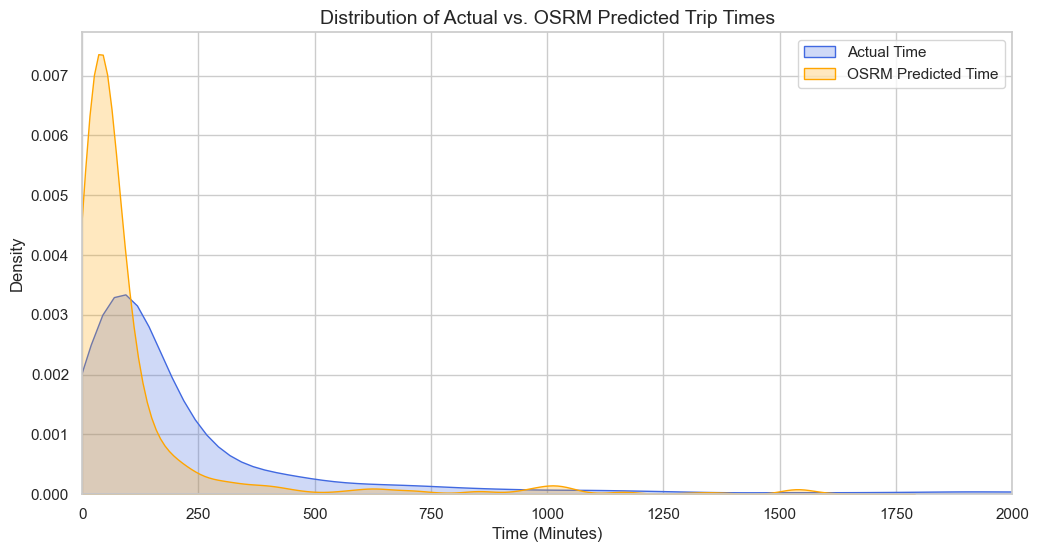

On average, actual trips take 2.86x longer than OSRM predictions.


In [4]:
# --- 5. VISUALIZING THE DELAY GAP ---
plt.figure(figsize=(12, 6))

# Plotting Actual vs OSRM Time distributions
sns.kdeplot(trip_df['actual_time'], label='Actual Time', fill=True, color='royalblue')
sns.kdeplot(trip_df['osrm_time'], label='OSRM Predicted Time', fill=True, color='orange')

plt.title('Distribution of Actual vs. OSRM Predicted Trip Times', fontsize=14)
plt.xlabel('Time (Minutes)')
plt.ylabel('Density')
plt.legend()

# Showing a limit on X-axis to focus on the majority of trips
plt.xlim(0, 2000) 
plt.show()

# Calculate the average delay factor
avg_delay_factor = (trip_df['actual_time'] / trip_df['osrm_time']).mean()
print(f"On average, actual trips take {avg_delay_factor:.2f}x longer than OSRM predictions.")

In [ ]:
5.1. Categorical EDA: Impact of Route Type
Analyzing how 'Carting' (local) vs. 'FTL' (Long-haul) affects the delay. This helps in understanding if the OSRM error is specific to certain logistics models.

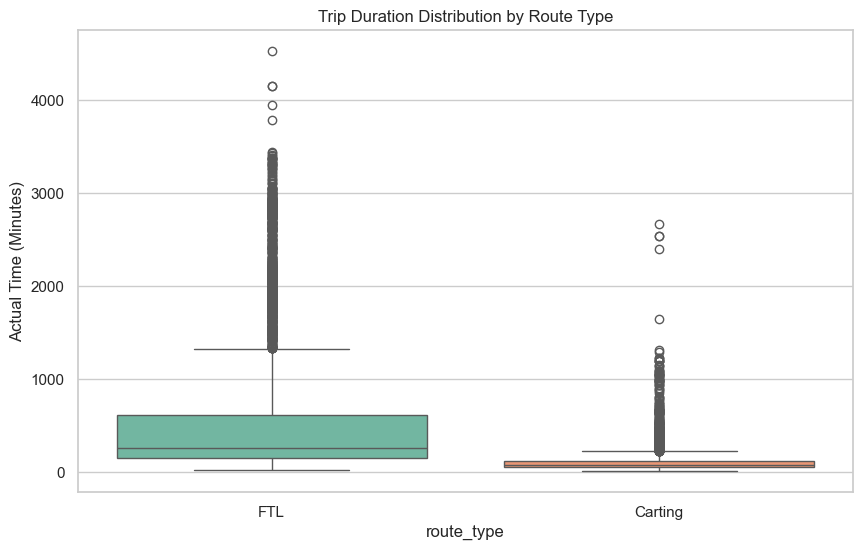

Average Delay Factor by Route Type:
route_type
Carting    3.067116
FTL        2.553904
dtype: float64


In [5]:
# Comparison of Actual vs OSRM by Route Type
plt.figure(figsize=(10, 6))
sns.boxplot(data=trip_df, x='route_type', y='actual_time', palette='Set2')
plt.title('Trip Duration Distribution by Route Type')
plt.ylabel('Actual Time (Minutes)')
plt.show()

# Calculating the specific delay per route type
route_summary = trip_df.groupby('route_type').apply(lambda x: (x['actual_time'] / x['osrm_time']).mean())
print("Average Delay Factor by Route Type:")
print(route_summary)

In [ ]:
6. Statistical Validation: T-Test for Significant VarianceHypothesis: 
Is the difference between Actual Time and OSRM Predicted Time statistically significant?
Null Hypothesis ($H_0$): There is no significant difference between Actual and OSRM times.
Alternative Hypothesis ($H_a$): Actual times are significantly higher than OSRM predictions.

In [6]:
from scipy.stats import ttest_rel

# Performing a Paired T-Test
t_stat, p_value = ttest_rel(trip_df['actual_time'], trip_df['osrm_time'])

print(f"T-statistic: {t_stat:.2f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("\nResult: Reject the Null Hypothesis.")
    print("Conclusion: The difference between Actual and OSRM times is statistically significant.")
else:
    print("\nResult: Fail to reject the Null Hypothesis.")

T-statistic: 70.66
P-value: 0.0000

Result: Reject the Null Hypothesis.
Conclusion: The difference between Actual and OSRM times is statistically significant.
